In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from students.vorobev.lesson3 import Exercise

In [2]:
digits = load_digits()
X, y = digits.data.astype(np.float32) / 16.0, digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Classes: {np.unique(y)}")

Train: (1617, 64), Test: (180, 64)
Classes: [0 1 2 3 4 5 6 7 8 9]


In [3]:
rng = np.random.default_rng(42)
model = Exercise.create_model(
    Exercise.create_linear_layer(64, 128, rng),
    Exercise.create_relu_layer(),
    Exercise.create_linear_layer(128, 64, rng),
    Exercise.create_relu_layer(),
    Exercise.create_linear_layer(64, 10, rng),
    Exercise.create_logsoftmax_layer(),
)
out = model.forward(X_train[:5])
print(f"Output shape: {out.shape}")

Output shape: (5, 10)


In [4]:
loss_fn = Exercise.create_nll_loss()
loss_val = loss_fn.forward(out, y_train[:5])
grad_val = loss_fn.backward()
print(f"Loss: {loss_val:.4f}")
print(f"Grad shape: {grad_val.shape}")

Loss: 2.2781
Grad shape: (5, 10)


In [5]:
lr, n_epoch, batch_size = 0.01, 20, 16
train_losses, test_losses, train_accs, test_accs = [], [], [], []
for epoch in range(n_epoch):
    idx = np.random.permutation(len(X_train))
    X_shuffled, y_shuffled = X_train[idx], y_train[idx]
    epoch_loss, correct = [], 0
    for i in range(0, len(X_train), batch_size):
        X_b, y_b = X_shuffled[i:i+batch_size], y_shuffled[i:i+batch_size]
        out = model.forward(X_b)
        loss = loss_fn.forward(out, y_b)
        epoch_loss.append(loss)
        correct += np.sum(np.argmax(out, axis=1) == y_b)
        model.backward(loss_fn.backward())
        for p, g in zip(model.parameters, model.grad, strict=True):
            p -= g * lr
    test_out = model.forward(X_test)
    test_loss = loss_fn.forward(test_out, y_test)
    test_acc = np.mean(np.argmax(test_out, axis=1) == y_test)
    train_losses.append(np.mean(epoch_loss))
    test_losses.append(test_loss)
    train_accs.append(correct / len(X_train))
    test_accs.append(test_acc)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1} | Train Loss: {train_losses[-1]:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

Epoch 10 | Train Loss: 1.7093 | Test Loss: 1.5928 | Test Acc: 0.7222
Epoch 20 | Train Loss: 0.4452 | Test Loss: 0.3989 | Test Acc: 0.9278


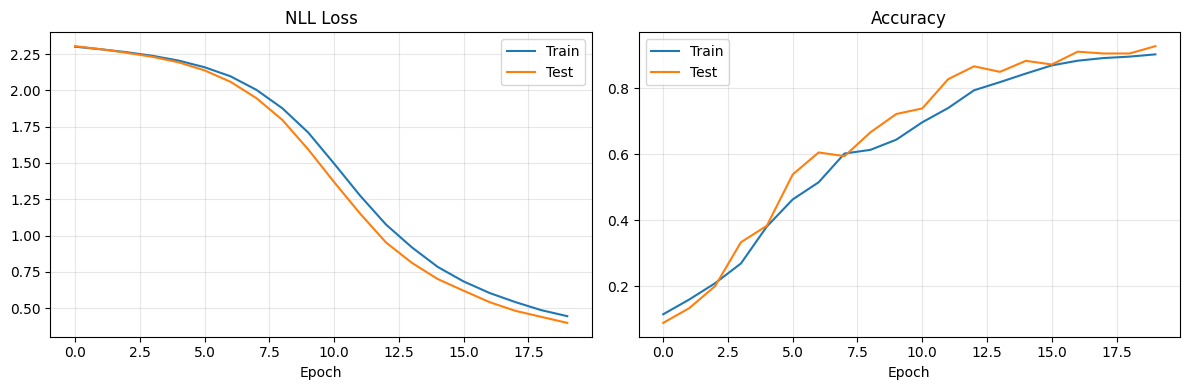

Final test accuracy: 0.9278


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label="Train")
ax1.plot(test_losses, label="Test")
ax1.set_title("NLL Loss")
ax1.set_xlabel("Epoch")
ax1.legend()
ax1.grid(alpha=0.3)
ax2.plot(train_accs, label="Train")
ax2.plot(test_accs, label="Test")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Final test accuracy: {test_accs[-1]:.4f}")